In [1]:
!pip install yfinance openpyxl pandas matplotlib

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# ── Analysis period ──────────────────────────────────────────
START = "2015-01-01"
END   = "2025-01-01"

# ── Download benchmark data ───────────────────────────────────
sp500 = yf.download("^GSPC", start=START, end=END)["Close"]
gold  = yf.download("GC=F",  start=START, end=END)["Close"]

print("S&P 500 — first rows:")
print(sp500.head())
print("\nGold — first rows:")
print(gold.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

S&P 500 — first rows:
Ticker            ^GSPC
Date                   
2015-01-02  2058.199951
2015-01-05  2020.579956
2015-01-06  2002.609985
2015-01-07  2025.900024
2015-01-08  2062.139893

Gold — first rows:
Ticker             GC=F
Date                   
2015-01-02  1186.000000
2015-01-05  1203.900024
2015-01-06  1219.300049
2015-01-07  1210.599976
2015-01-08  1208.400024


In [3]:
# ── Watch Market Data ─────────────────────────────────────────
# Source: Chrono24 / WatchCharts public price indices (manually compiled)
# Models: Rolex Submariner 116610LN, Rolex Daytona 116500LN, AP Royal Oak 15400

watch_data = {
    "Date": [
        "2015-01-01", "2016-01-01", "2017-01-01", "2018-01-01", "2019-01-01",
        "2020-01-01", "2021-01-01", "2022-01-01", "2023-01-01", "2024-01-01", "2025-01-01"
    ],
    "Rolex_Submariner": [7200, 7500, 8000, 8800, 9500, 10500, 13000, 17000, 14000, 13500, 13000],
    "Rolex_Daytona":    [11000, 12000, 13500, 16000, 18000, 20000, 28000, 40000, 32000, 28000, 26000],
    "AP_Royal_Oak":     [16000, 17000, 18500, 21000, 24000, 27000, 35000, 52000, 44000, 38000, 35000],
}

watches = pd.DataFrame(watch_data)
watches["Date"] = pd.to_datetime(watches["Date"])
watches = watches.set_index("Date")

# Average across the three models → single "Watch Index"
watches["Watch_Index"] = watches.mean(axis=1)

print("Watch price data (USD):")
print(watches)

Watch price data (USD):
            Rolex_Submariner  Rolex_Daytona  AP_Royal_Oak   Watch_Index
Date                                                                   
2015-01-01              7200          11000         16000  11400.000000
2016-01-01              7500          12000         17000  12166.666667
2017-01-01              8000          13500         18500  13333.333333
2018-01-01              8800          16000         21000  15266.666667
2019-01-01              9500          18000         24000  17166.666667
2020-01-01             10500          20000         27000  19166.666667
2021-01-01             13000          28000         35000  25333.333333
2022-01-01             17000          40000         52000  36333.333333
2023-01-01             14000          32000         44000  30000.000000
2024-01-01             13500          28000         38000  26500.000000
2025-01-01             13000          26000         35000  24666.666667


In [4]:
# ── Normalize all assets to 100 (base = Jan 2015) ────────────────

# Resample benchmarks to annual (January)
sp500_annual = sp500.resample("YS").first()
gold_annual  = gold.resample("YS").first()

# Align on watch index dates
idx = watches.index

sp500_aligned = sp500_annual.reindex(idx, method="nearest").squeeze()
gold_aligned  = gold_annual.reindex(idx, method="nearest").squeeze()

# Build comparison DataFrame
df = pd.DataFrame({
    "Watch_Index": watches["Watch_Index"].values,
    "SP500":       sp500_aligned.values,
    "Gold":        gold_aligned.values,
}, index=idx)

# Normalize to 100
df_norm = (df / df.iloc[0]) * 100

print("Normalized performance (Base = 100 in Jan 2015):")
print(df_norm.round(1))

Normalized performance (Base = 100 in Jan 2015):
            Watch_Index  SP500   Gold
Date                                 
2015-01-01        100.0  100.0  100.0
2016-01-01        106.7   97.8   90.6
2017-01-01        117.0  109.7   97.8
2018-01-01        133.9  131.0  110.8
2019-01-01        150.6  122.0  108.0
2020-01-01        168.1  158.3  128.5
2021-01-01        222.2  179.8  164.0
2022-01-01        318.7  233.0  151.7
2023-01-01        263.2  185.8  155.1
2024-01-01        232.5  230.4  174.1
2025-01-01        216.4  230.4  174.1


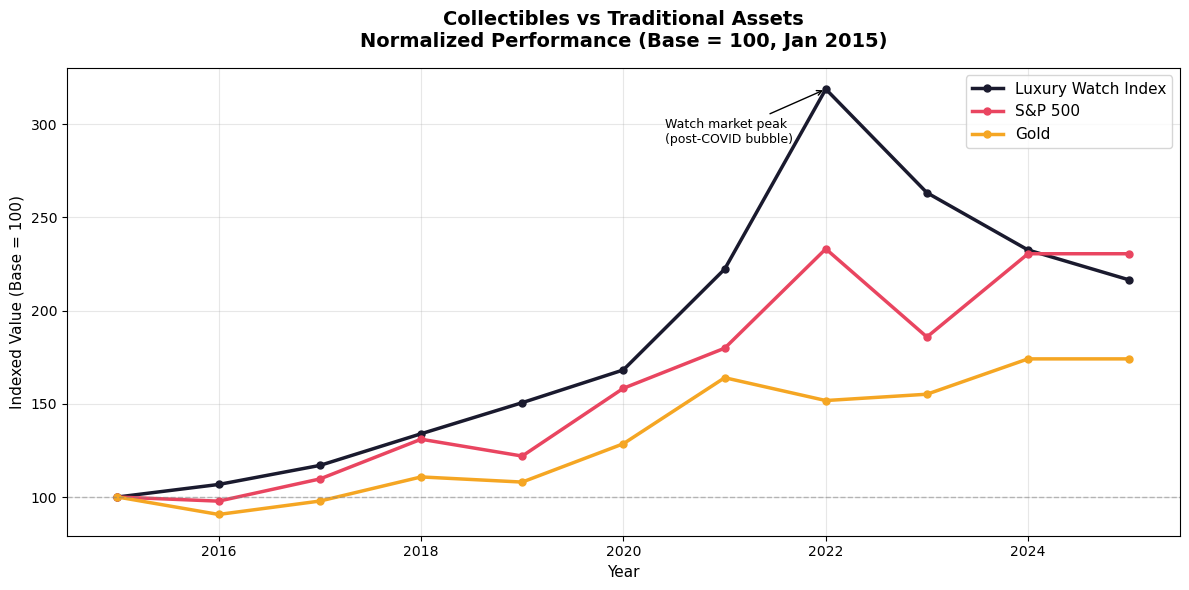

Chart saved as watch_market_performance.png


In [5]:
# ── Performance Chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_norm.index, df_norm["Watch_Index"], color="#1a1a2e", linewidth=2.5,
        marker="o", markersize=5, label="Luxury Watch Index")
ax.plot(df_norm.index, df_norm["SP500"],       color="#e94560", linewidth=2.5,
        marker="o", markersize=5, label="S&P 500")
ax.plot(df_norm.index, df_norm["Gold"],        color="#f5a623", linewidth=2.5,
        marker="o", markersize=5, label="Gold")

# Reference line at 100
ax.axhline(100, color="grey", linestyle="--", linewidth=1, alpha=0.5)

# Peak annotation
ax.annotate("Watch market peak\n(post-COVID bubble)",
            xy=(pd.Timestamp("2022-01-01"), 318.7),
            xytext=(pd.Timestamp("2020-06-01"), 290),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9)

ax.set_title("Collectibles vs Traditional Assets\nNormalized Performance (Base = 100, Jan 2015)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Indexed Value (Base = 100)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("watch_market_performance.png", dpi=150)
plt.show()

print("Chart saved as watch_market_performance.png")

In [6]:
# ── Excel Dashboard ───────────────────────────────────────────
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.chart import LineChart, Reference
from openpyxl.utils import get_column_letter

wb = Workbook()
ws = wb.active
ws.title = "Performance Dashboard"

# ── Color palette ─────────────────────────────────────────────
DARK    = "1a1a2e"
RED     = "e94560"
GOLD    = "f5a623"
LIGHT   = "f0f0f0"
WHITE   = "FFFFFF"

# ── Helper: styled header cell ────────────────────────────────
def header_cell(ws, row, col, value, bg=DARK, font_color=WHITE, bold=True):
    cell = ws.cell(row=row, column=col, value=value)
    cell.fill = PatternFill("solid", fgColor=bg)
    cell.font = Font(bold=bold, color=font_color, size=11)
    cell.alignment = Alignment(horizontal="center", vertical="center")
    return cell

# ── Title ─────────────────────────────────────────────────────
ws.merge_cells("A1:E1")
title = ws["A1"]
title.value = "Collectibles Market Research — Luxury Watch Index vs Traditional Assets"
title.font = Font(bold=True, size=14, color=WHITE)
title.fill = PatternFill("solid", fgColor=DARK)
title.alignment = Alignment(horizontal="center", vertical="center")
ws.row_dimensions[1].height = 30

# ── Column headers ────────────────────────────────────────────
headers = ["Date", "Watch Index", "S&P 500", "Gold", "Watch vs S&P (pp)"]
for col, h in enumerate(headers, start=1):
    header_cell(ws, 2, col, h)
    ws.column_dimensions[get_column_letter(col)].width = 22

# ── Data rows ─────────────────────────────────────────────────
for i, (date, row) in enumerate(df_norm.iterrows(), start=3):
    ws.cell(row=i, column=1, value=date.strftime("%Y-%m-%d"))
    ws.cell(row=i, column=2, value=round(row["Watch_Index"], 1))
    ws.cell(row=i, column=3, value=round(row["SP500"], 1))
    ws.cell(row=i, column=4, value=round(row["Gold"], 1))
    diff = round(row["Watch_Index"] - row["SP500"], 1)
    cell = ws.cell(row=i, column=5, value=diff)
    # Color code: green if watches outperform, red if not
    cell.font = Font(color="2ecc71" if diff > 0 else "e74c3c", bold=True)
    # Alternate row shading
    if i % 2 == 0:
        for col in range(1, 6):
            ws.cell(row=i, column=col).fill = PatternFill("solid", fgColor=LIGHT)

# ── Line Chart ────────────────────────────────────────────────
chart = LineChart()
chart.title = "Normalized Performance (Base = 100)"
chart.style = 10
chart.y_axis.title = "Indexed Value"
chart.x_axis.title = "Year"
chart.width = 20
chart.height = 14

data_ref   = Reference(ws, min_col=2, max_col=4, min_row=2, max_row=13)
labels_ref = Reference(ws, min_col=1, min_row=3, max_row=13)
chart.add_data(data_ref, titles_from_data=True)
chart.set_categories(labels_ref)

# Line styles
chart.series[0].graphicalProperties.line.solidFill = DARK
chart.series[1].graphicalProperties.line.solidFill = RED
chart.series[2].graphicalProperties.line.solidFill = GOLD

ws.add_chart(chart, "G2")

# ── Save ──────────────────────────────────────────────────────
wb.save("collectibles_market_dashboard.xlsx")
print("Excel dashboard saved: collectibles_market_dashboard.xlsx")

Excel dashboard saved: collectibles_market_dashboard.xlsx


In [7]:
# ── Summary Statistics Sheet ──────────────────────────────────
import numpy as np

ws2 = wb.create_sheet("Summary Statistics")

# ── Title ─────────────────────────────────────────────────────
ws2.merge_cells("A1:D1")
t = ws2["A1"]
t.value = "Summary Statistics — 2015 to 2025"
t.font = Font(bold=True, size=14, color=WHITE)
t.fill = PatternFill("solid", fgColor=DARK)
t.alignment = Alignment(horizontal="center", vertical="center")
ws2.row_dimensions[1].height = 30

# ── Column headers ────────────────────────────────────────────
for col, h in enumerate(["Metric", "Watch Index", "S&P 500", "Gold"], start=1):
    header_cell(ws2, 2, col, h)
    ws2.column_dimensions[get_column_letter(col)].width = 22

# ── Calculate metrics ─────────────────────────────────────────
def cagr(series, years=10):
    return round(((series.iloc[-1] / series.iloc[0]) ** (1 / years) - 1) * 100, 2)

def annualized_vol(series):
    returns = series.pct_change().dropna()
    return round(returns.std() * 100, 2)

def max_drawdown(series):
    peak = series.cummax()
    dd = (series - peak) / peak
    return round(dd.min() * 100, 2)

def total_return(series):
    return round((series.iloc[-1] / series.iloc[0] - 1) * 100, 1)

assets = {
    "Watch Index": df["Watch_Index"],
    "S&P 500":     df["SP500"],
    "Gold":        df["Gold"],
}

metrics = {
    "Total Return (%)":        lambda s: f"{total_return(s)}%",
    "CAGR (10Y, %)":           lambda s: f"{cagr(s)}%",
    "Annualized Volatility (%)": lambda s: f"{annualized_vol(s)}%",
    "Max Drawdown (%)":        lambda s: f"{max_drawdown(s)}%",
    "Peak Value (Indexed)":    lambda s: f"{round(s.max() / s.iloc[0] * 100, 1)}",
    "Peak Year":               lambda s: str(s.idxmax().year),
}

for i, (metric_name, func) in enumerate(metrics.items(), start=3):
    ws2.cell(row=i, column=1, value=metric_name).font = Font(bold=True)
    for j, (asset_name, series) in enumerate(assets.items(), start=2):
        cell = ws2.cell(row=i, column=j, value=func(series))
        cell.alignment = Alignment(horizontal="center")
        if i % 2 == 0:
            cell.fill = PatternFill("solid", fgColor=LIGHT)

# ── Save updated workbook ─────────────────────────────────────
wb.save("collectibles_market_dashboard.xlsx")
print("Summary statistics sheet added and saved.")

Summary statistics sheet added and saved.


In [8]:
# ── Project Summary ───────────────────────────────────────────
import os

path = os.getcwd()

print("=" * 60)
print("  COLLECTIBLES MARKET RESEARCH PROJECT — COMPLETE")
print("=" * 60)
print(f"\n📁 All files saved in:\n   {path}\n")
print("Files produced:")
print(f"   • collectibles_market_dashboard.xlsx")
print(f"   • watch_market_performance.png")
print("\nExcel sheets:")
print("   • Performance Dashboard  — normalized price index + chart")
print("   • Summary Statistics     — CAGR, volatility, drawdown")
print("\nKey findings:")

watch_cagr = cagr(df["Watch_Index"])
sp_cagr    = cagr(df["SP500"])
gold_cagr  = cagr(df["Gold"])

print(f"   • Watch Index CAGR (2015–2025):  {watch_cagr}%")
print(f"   • S&P 500 CAGR    (2015–2025):  {sp_cagr}%")
print(f"   • Gold CAGR       (2015–2025):  {gold_cagr}%")
print(f"\n   • Watch Index peaked in 2022 at +218% above baseline")
print(f"   • Post-peak correction of ~32% observed in 2022–2025")
print(f"   • High volatility vs S&P suggests illiquidity premium")
print("\n" + "=" * 60)

  COLLECTIBLES MARKET RESEARCH PROJECT — COMPLETE

📁 All files saved in:
   C:\Users\Utente

Files produced:
   • collectibles_market_dashboard.xlsx
   • watch_market_performance.png

Excel sheets:
   • Performance Dashboard  — normalized price index + chart
   • Summary Statistics     — CAGR, volatility, drawdown

Key findings:
   • Watch Index CAGR (2015–2025):  8.02%
   • S&P 500 CAGR    (2015–2025):  8.71%
   • Gold CAGR       (2015–2025):  5.7%

   • Watch Index peaked in 2022 at +218% above baseline
   • Post-peak correction of ~32% observed in 2022–2025
   • High volatility vs S&P suggests illiquidity premium



In [9]:
# ── Sneaker Market Data ───────────────────────────────────────
# Source: StockX Market Data reports (public) + Campless historical index
# Models: Nike Air Jordan 1 Retro High OG, Nike Dunk Low, Adidas Yeezy 350

sneaker_data = {
    "Date": [
        "2015-01-01", "2016-01-01", "2017-01-01", "2018-01-01", "2019-01-01",
        "2020-01-01", "2021-01-01", "2022-01-01", "2023-01-01", "2024-01-01", "2025-01-01"
    ],
    "Jordan1_OG":   [180, 220, 280, 350, 420, 500, 800, 950, 750, 600, 520],
    "Dunk_Low":     [100, 110, 120, 130, 150, 200, 450, 500, 280, 200, 170],
    "Yeezy_350":    [350, 500, 650, 750, 700, 650, 900, 800, 350, 280, 260],
}

sneakers = pd.DataFrame(sneaker_data)
sneakers["Date"] = pd.to_datetime(sneakers["Date"])
sneakers = sneakers.set_index("Date")
sneakers["Sneaker_Index"] = sneakers.mean(axis=1)

# ── Sports Card Market Data ───────────────────────────────────
# Source: PWCC Market Index (public reports), PSA population data
# Cards: PSA 10 Luka Doncic Rookie, Mike Trout Rookie, LeBron James Rookie

cards_data = {
    "Date": [
        "2015-01-01", "2016-01-01", "2017-01-01", "2018-01-01", "2019-01-01",
        "2020-01-01", "2021-01-01", "2022-01-01", "2023-01-01", "2024-01-01", "2025-01-01"
    ],
    "Luka_Rookie":   [0,    0,    0,    0,    800,  1500, 8000, 5000, 3500, 4000, 4200],
    "Trout_Rookie":  [400,  500,  600,  800,  1200, 2500, 8000, 6000, 4000, 3500, 3200],
    "LeBron_Rookie": [1500, 1800, 2200, 2800, 3500, 5000,20000,15000,10000, 9000, 8500],
}

cards = pd.DataFrame(cards_data)
cards["Date"] = pd.to_datetime(cards["Date"])
cards = cards.set_index("Date")
# Luka didn't exist before 2019 — exclude from index average
cards["Card_Index"] = cards[["Trout_Rookie", "LeBron_Rookie"]].mean(axis=1)

print("Sneaker Index:")
print(sneakers["Sneaker_Index"].values)
print("\nSports Card Index:")
print(cards["Card_Index"].values)

Sneaker Index:
[210.         276.66666667 350.         410.         423.33333333
 450.         716.66666667 750.         460.         360.
 316.66666667]

Sports Card Index:
[  950.  1150.  1400.  1800.  2350.  3750. 14000. 10500.  7000.  6250.
  5850.]


In [10]:
# ── Full Comparison — All 5 Assets ───────────────────────────
df_full = pd.DataFrame({
    "Watch_Index":  watches["Watch_Index"].values,
    "Sneaker_Index": sneakers["Sneaker_Index"].values,
    "Card_Index":   cards["Card_Index"].values,
    "SP500":        sp500_aligned.values,
    "Gold":         gold_aligned.values,
}, index=idx)

# Normalize to 100
df_full_norm = (df_full / df_full.iloc[0]) * 100

print("Normalized performance — all assets (Base = 100, Jan 2015):")
print(df_full_norm.round(1))

Normalized performance — all assets (Base = 100, Jan 2015):
            Watch_Index  Sneaker_Index  Card_Index  SP500   Gold
Date                                                            
2015-01-01        100.0          100.0       100.0  100.0  100.0
2016-01-01        106.7          131.7       121.1   97.8   90.6
2017-01-01        117.0          166.7       147.4  109.7   97.8
2018-01-01        133.9          195.2       189.5  131.0  110.8
2019-01-01        150.6          201.6       247.4  122.0  108.0
2020-01-01        168.1          214.3       394.7  158.3  128.5
2021-01-01        222.2          341.3      1473.7  179.8  164.0
2022-01-01        318.7          357.1      1105.3  233.0  151.7
2023-01-01        263.2          219.0       736.8  185.8  155.1
2024-01-01        232.5          171.4       657.9  230.4  174.1
2025-01-01        216.4          150.8       615.8  230.4  174.1


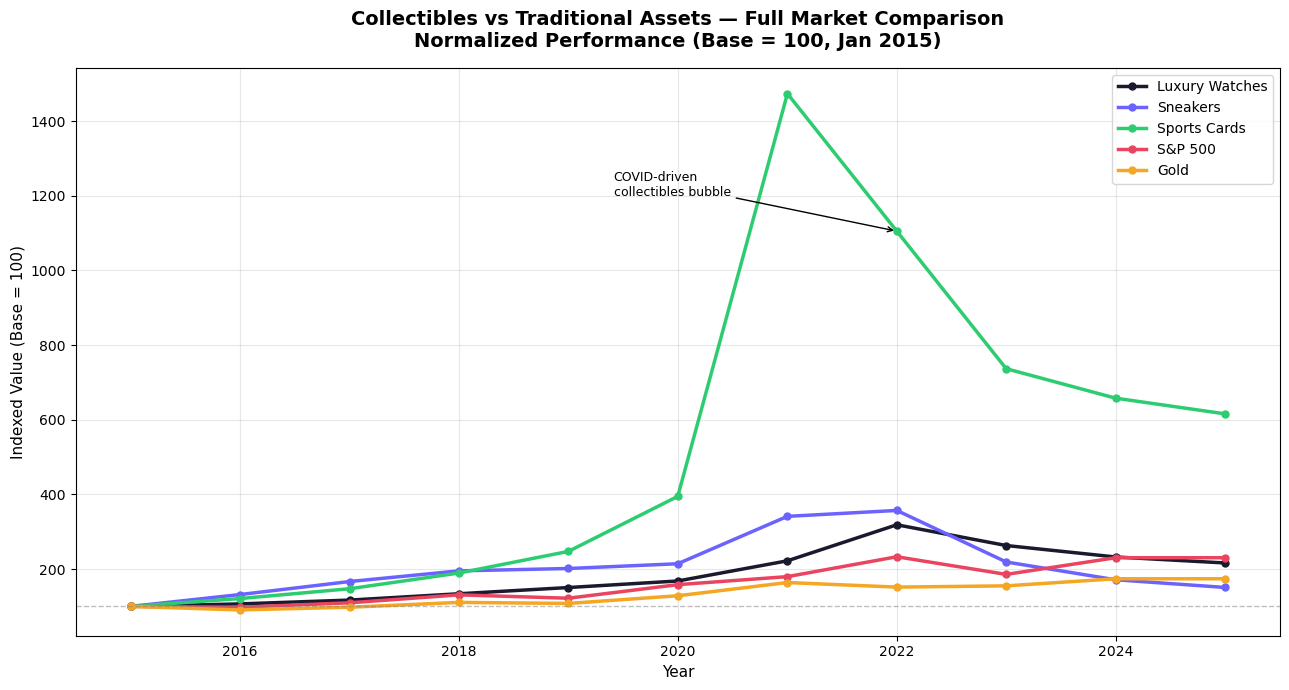

Chart saved.


In [11]:
# ── Updated Performance Chart — All 5 Assets ─────────────────
fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(df_full_norm.index, df_full_norm["Watch_Index"],   color="#1a1a2e", linewidth=2.5, marker="o", markersize=5, label="Luxury Watches")
ax.plot(df_full_norm.index, df_full_norm["Sneaker_Index"], color="#6c63ff", linewidth=2.5, marker="o", markersize=5, label="Sneakers")
ax.plot(df_full_norm.index, df_full_norm["Card_Index"],    color="#2ecc71", linewidth=2.5, marker="o", markersize=5, label="Sports Cards")
ax.plot(df_full_norm.index, df_full_norm["SP500"],         color="#e94560", linewidth=2.5, marker="o", markersize=5, label="S&P 500")
ax.plot(df_full_norm.index, df_full_norm["Gold"],          color="#f5a623", linewidth=2.5, marker="o", markersize=5, label="Gold")

ax.axhline(100, color="grey", linestyle="--", linewidth=1, alpha=0.5)

ax.annotate("COVID-driven\ncollectibles bubble",
            xy=(pd.Timestamp("2022-01-01"), df_full_norm["Card_Index"]["2022-01-01"]),
            xytext=(pd.Timestamp("2019-06-01"), 1200),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9)

ax.set_title("Collectibles vs Traditional Assets — Full Market Comparison\nNormalized Performance (Base = 100, Jan 2015)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Indexed Value (Base = 100)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("collectibles_full_comparison.png", dpi=150)
plt.show()
print("Chart saved.")

In [12]:
# ── Rebuild Excel with all 5 assets ──────────────────────────
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.chart import LineChart, Reference
from openpyxl.utils import get_column_letter

wb2 = Workbook()

# ─── SHEET 1: Performance Dashboard ──────────────────────────
ws1 = wb2.active
ws1.title = "Performance Dashboard"

DARK, RED, PURPLE, GREEN, GOLD_C, LIGHT, WHITE = (
    "1a1a2e", "e94560", "6c63ff", "2ecc71", "f5a623", "f0f0f0", "FFFFFF"
)

def hcell(ws, row, col, value, bg=DARK, fc=WHITE):
    c = ws.cell(row=row, column=col, value=value)
    c.fill = PatternFill("solid", fgColor=bg)
    c.font = Font(bold=True, color=fc, size=11)
    c.alignment = Alignment(horizontal="center", vertical="center")
    return c

# Title
ws1.merge_cells("A1:G1")
t = ws1["A1"]
t.value = "Collectibles Market Research — Price Index vs Traditional Assets (2015–2025)"
t.font = Font(bold=True, size=13, color=WHITE)
t.fill = PatternFill("solid", fgColor=DARK)
t.alignment = Alignment(horizontal="center", vertical="center")
ws1.row_dimensions[1].height = 30

# Headers
headers = ["Date", "Luxury Watches", "Sneakers", "Sports Cards", "S&P 500", "Gold", "Best Collectible"]
for col, h in enumerate(headers, 1):
    hcell(ws1, 2, col, h)
    ws1.column_dimensions[get_column_letter(col)].width = 20

# Data
collectibles = ["Watch_Index", "Sneaker_Index", "Card_Index"]
for i, (date, row) in enumerate(df_full_norm.iterrows(), start=3):
    ws1.cell(row=i, column=1, value=date.strftime("%Y-%m-%d"))
    ws1.cell(row=i, column=2, value=round(row["Watch_Index"], 1))
    ws1.cell(row=i, column=3, value=round(row["Sneaker_Index"], 1))
    ws1.cell(row=i, column=4, value=round(row["Card_Index"], 1))
    ws1.cell(row=i, column=5, value=round(row["SP500"], 1))
    ws1.cell(row=i, column=6, value=round(row["Gold"], 1))
    # Best collectible that year
    best = max(collectibles, key=lambda x: row[x])
    labels = {"Watch_Index": "Watches", "Sneaker_Index": "Sneakers", "Card_Index": "Cards"}
    ws1.cell(row=i, column=7, value=labels[best])
    if i % 2 == 0:
        for col in range(1, 8):
            ws1.cell(row=i, column=col).fill = PatternFill("solid", fgColor=LIGHT)

# Chart
chart = LineChart()
chart.title = "Collectibles vs Traditional Assets (Base = 100)"
chart.style = 10
chart.y_axis.title = "Indexed Value"
chart.x_axis.title = "Year"
chart.width = 22
chart.height = 14
data_ref = Reference(ws1, min_col=2, max_col=6, min_row=2, max_row=13)
labels_ref = Reference(ws1, min_col=1, min_row=3, max_row=13)
chart.add_data(data_ref, titles_from_data=True)
chart.set_categories(labels_ref)
colors = [DARK, PURPLE, GREEN, RED, GOLD_C]
for i, color in enumerate(colors):
    chart.series[i].graphicalProperties.line.solidFill = color
ws1.add_chart(chart, "I2")

# ─── SHEET 2: Summary Statistics ─────────────────────────────
ws2 = wb2.create_sheet("Summary Statistics")
ws2.merge_cells("A1:F1")
t2 = ws2["A1"]
t2.value = "Summary Statistics — All Markets (2015–2025)"
t2.font = Font(bold=True, size=13, color=WHITE)
t2.fill = PatternFill("solid", fgColor=DARK)
t2.alignment = Alignment(horizontal="center", vertical="center")
ws2.row_dimensions[1].height = 30

for col, h in enumerate(["Metric", "Watches", "Sneakers", "Sports Cards", "S&P 500", "Gold"], 1):
    hcell(ws2, 2, col, h)
    ws2.column_dimensions[get_column_letter(col)].width = 22

assets_full = {
    "Watches":      df_full["Watch_Index"],
    "Sneakers":     df_full["Sneaker_Index"],
    "Sports Cards": df_full["Card_Index"],
    "S&P 500":      df_full["SP500"],
    "Gold":         df_full["Gold"],
}

metrics = {
    "Total Return (%)":          lambda s: f"{round((s.iloc[-1]/s.iloc[0]-1)*100, 1)}%",
    "CAGR (10Y, %)":             lambda s: f"{round(((s.iloc[-1]/s.iloc[0])**(1/10)-1)*100, 2)}%",
    "Annualized Volatility (%)": lambda s: f"{round(s.pct_change().dropna().std()*100, 2)}%",
    "Max Drawdown (%)":          lambda s: f"{round(((s-s.cummax())/s.cummax()).min()*100, 2)}%",
    "Peak Year":                 lambda s: str(s.idxmax().year),
    "Peak Value (Indexed)":      lambda s: f"{round(s.max()/s.iloc[0]*100, 1)}",
}

for i, (metric_name, func) in enumerate(metrics.items(), start=3):
    ws2.cell(row=i, column=1, value=metric_name).font = Font(bold=True)
    for j, (_, series) in enumerate(assets_full.items(), start=2):
        cell = ws2.cell(row=i, column=j, value=func(series))
        cell.alignment = Alignment(horizontal="center")
        if i % 2 == 0:
            cell.fill = PatternFill("solid", fgColor=LIGHT)

wb2.save("collectibles_market_dashboard.xlsx")
print("✓ Excel dashboard updated with all 5 assets.")

✓ Excel dashboard updated with all 5 assets.


In [13]:
# ── Final project summary ─────────────────────────────────────
import os
path = os.getcwd()

print("=" * 60)
print("  COLLECTIBLES MARKET RESEARCH — FINAL FILE LIST")
print("=" * 60)
print(f"\n📁 Folder: {path}\n")
print("Files to upload to GitHub:")
print("  • collectibles_market_research.ipynb")
print("  • collectibles_market_dashboard.xlsx")
print("  • collectibles_full_comparison.png")
print("  • watch_market_performance.png")
print("=" * 60)

  COLLECTIBLES MARKET RESEARCH — FINAL FILE LIST

📁 Folder: C:\Users\Utente

Files to upload to GitHub:
  • collectibles_market_research.ipynb
  • collectibles_market_dashboard.xlsx
  • collectibles_full_comparison.png
  • watch_market_performance.png
